# Epoch Spring Camp 2026 - Take Home Task 3

In this task, you will build and compare two recommender system models:

- **Matrix Factorization (MF)** using a dot product of embeddings  
- **Neural Collaborative Filtering (MLP-based)** using a multi-layer perceptron  

You are provided with:
- Preprocessed interaction data
- Evaluation pipeline

You are expected to implement:
- Negative sampling
- Model architectures
- Training loop

---

The purpose of this task is to understand how neural networks can model user–item interactions beyond simple similarity.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import sys
import seaborn as sns

np.random.seed(42)
torch.manual_seed(42)
# set the seeds for reproducibility

## Loading Data

We begin by loading the interaction data.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aneeshshastri/epoch-task-3/interactions.csv")  # columns: user_id, movie_id
items=df['item_id'].unique()
users=df['user_id'].unique()

print("Num users:", df['user_id'].nunique())
print("Num items:", df['item_id'].nunique())
print("Num interactions:", len(df))

Num users: 942
Num items: 1447
Num interactions: 55375


(array([10., 56., 77., 56., 68., 68., 54., 20., 38., 35., 47., 18., 37.,
        17., 18.,  8., 17., 18., 21.,  8., 17.,  9., 18.,  8., 10.,  9.,
        11.,  6., 10., 12.,  9.,  8.,  6., 10.,  5.,  5., 11.,  8.,  9.,
         3.,  6.,  3.,  7.,  1.,  3.,  3.,  7.,  4.,  3.,  2.,  1.,  2.,
         2.,  1.,  2.,  1.,  2.,  0.,  0.,  1.,  0.,  1.,  0.,  2.,  1.,
         0.,  1.,  4.,  1.,  0.,  1.,  0.,  2.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([  3.  ,   6.75,  10.5 ,  14.25,  18.  ,  21.75,  25.5 ,  29.25,
         33.  ,  36.75,  40.5 ,  44.25,  48.  ,  51.75,  55.5 ,  59.25,
         63.  ,  66.75,  70.5 ,  74.25,  78.  ,  81.75,  85.5 ,  89.25,
         93.  ,  96.75, 100.5 , 104.25, 108.  , 111.75, 115.5 , 119.25,
        123.  , 126.75, 130.5 , 134.25, 138.  , 141.75, 145.5 , 149.25,
        153.  , 156.75, 160.5 , 164.25, 168.  , 171.75, 175.5 , 179.25,
  

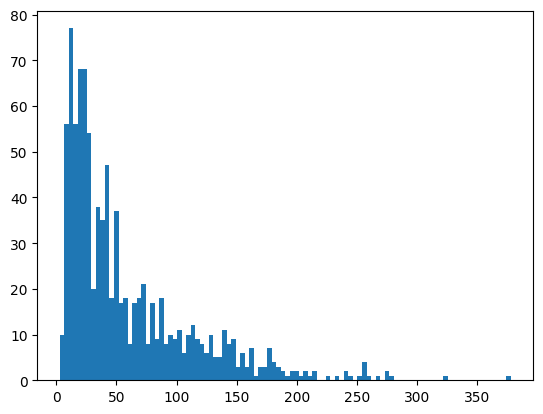

In [3]:
plt.hist(df['user_id'].value_counts(),bins=100) # look at the distributions of users and items

(array([491., 169., 109.,  73.,  48.,  54.,  49.,  43.,  34.,  35.,  34.,
         20.,  18.,  19.,  14.,  13.,  13.,  17.,  16.,  18.,  11.,   7.,
         12.,   5.,   5.,   7.,   7.,   7.,   5.,   5.,  11.,   2.,   6.,
          7.,   2.,   3.,   6.,   5.,   2.,   3.,   0.,   3.,   1.,   4.,
          4.,   3.,   4.,   2.,   1.,   3.,   2.,   0.,   3.,   0.,   0.,
          0.,   1.,   0.,   2.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   2.,   1.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([  1.,   6.,  11.,  16.,  21.,  26.,  31.,  36.,  41.,  46.,  51.,
         56.,  61.,  66.,  71.,  76.,  81.,  86.,  91.,  96., 101., 106.,
        111., 116., 121., 126., 131., 136., 141., 146., 151., 156., 161.,
        166., 171., 176., 181., 186., 191., 196., 201., 206., 211., 216.,
        221., 226., 23

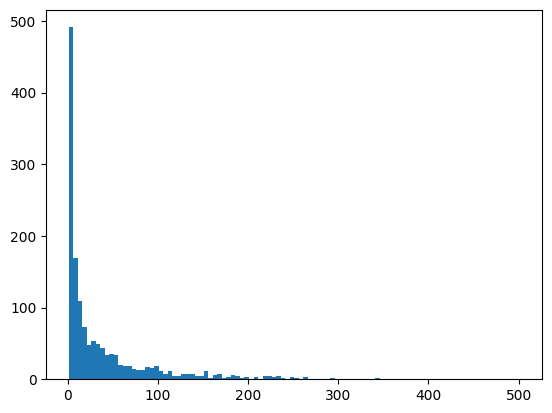

In [4]:
plt.hist(df['item_id'].value_counts(),bins=100)

Each row represents a **positive interaction** (implicit feedback).

## Train / Test Split

We split the data into training and testing sets.

The model will learn from the training data and be evaluated on unseen interactions in the test set.

Note: Previously, the splitting logic was a random split. This kind of splitting is highly skewed towards highly interacting users. On top of that, there are risks of certain low interaction users to not get any interactions at all in the train set, or getting all their interactions in the train set


In [5]:
from sklearn.model_selection import train_test_split

test_df = df.groupby('user_id').sample(n=1, random_state=42)

remainder_df = df.drop(test_df.index)


valid_df = remainder_df.groupby('user_id').sample(n=1, random_state=42)


train_df = remainder_df.drop(valid_df.index)

print(f"Train size: {len(train_df)}")
print(f"Valid size: {len(valid_df)}")
print(f"Test size:  {len(test_df)}")

Train size: 53491
Valid size: 942
Test size:  942


## PyTorch Dataset

We now wrap our processed data into a PyTorch `Dataset`.

This allows us to:
- Access individual samples as `(user, item, label)`
- Easily plug into a `DataLoader` for batching

You do not need to modify this part

(Well, I'm.. kinda going to do that anyways.

Instead of putting a static sample negatives function that injects the negative samples into the data, I modify the dataset directly. This is so I can inject randomness during training, so the model doesn't end up memorising the same set of negative samples it saw during training)


In [6]:
class InteractionDataset(Dataset):
    def __init__(self, df, all_items, num_neg=4, alpha=10):
        self.users = df['user_id'].values.astype(int)
        self.pos_items = df['item_id'].values.astype(int)
        self.all_items = all_items.astype(int)
        self.num_neg = num_neg
        self.user_interacted = df.groupby('user_id')['item_id'].apply(set).to_dict()
        
        # 1. Calculate frequencies (N_u) from the training dataframe
        counts = df['user_id'].value_counts().to_dict()
        self.weights_map = {u: 1.0 / (count + alpha) for u, count in counts.items()}

    def __len__(self):
        return len(self.users) * (1 + self.num_neg)

    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.num_neg)
        is_pos = (idx % (1 + self.num_neg)) == 0
        u = self.users[pos_idx]

        if is_pos:
            i = self.pos_items[pos_idx]
            label = 1.0
        else:
            i = random.choice(self.all_items)
            interacted = self.user_interacted.get(u, set())
            while i in interacted:
                i = random.choice(self.all_items)
            label = 0.0

        weight = self.weights_map[u]

        return (torch.tensor(u, dtype=torch.long), 
                torch.tensor(i, dtype=torch.long), 
                torch.tensor(label, dtype=torch.float32),
                torch.tensor(weight, dtype=torch.float32)) 

In [7]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class PositiveInteractionDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_id'].values.astype(np.int64))
        self.items = torch.tensor(df['item_id'].values.astype(np.int64))

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx]

## DataLoader

The `DataLoader` will:
- Batch the data
- Shuffle the training data
- Feed it to the model during training

In [8]:

train_loader = DataLoader(InteractionDataset(train_df,all_items=items,num_neg=10), batch_size=256, shuffle=True)
valid_loader = DataLoader(InteractionDataset(valid_df,all_items=items,num_neg=10), batch_size=256, shuffle=False)
valid_hit_loader = DataLoader(PositiveInteractionDataset(valid_df), batch_size=256, shuffle=False)

Why are we sampling negatives only for the training data?

## Quick Exploration

Before building models, take a moment to explore the data.

Try to understand:
- How many interactions each user has
- How popular certain items are

This can give intuition about the dataset.

In [9]:
# Interactions per user
user_counts = df['user_id'].value_counts()
print(user_counts.describe())

# Interactions per item
item_counts = df['item_id'].value_counts()
print(item_counts.describe())

count    942.000000
mean      58.784501
std       54.696664
min        3.000000
25%       19.000000
50%       39.500000
75%       80.750000
max      378.000000
Name: count, dtype: float64
count    1447.000000
mean       38.268832
std        57.956847
min         1.000000
25%         3.000000
50%        13.000000
75%        47.500000
max       501.000000
Name: count, dtype: float64


## Baseline Model: Matrix Factorization (MF)

We represent:
- Each **user** as a vector (embedding)
- Each **item** as a vector (embedding)

To predict interaction:
- Compute the **dot product** between user and item embeddings

This gives a **score** indicating how likely the user is to interact with the item.

---

### Your Task

Implement a model that:
1. Learns user and item embeddings
2. Computes their dot product as the output score

In [10]:
class MF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()

        # TODO:
        # - Define user embedding layer
        # - Define item embedding layer
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

    def forward(self, user, item):
        # TODO:
        # - Get user and item embeddings
        # - Compute dot product
        # - Return a single score per pair
        user_emb = self.user_emb(user)
        item_emb = self.item_emb(item)
        return (user_emb * item_emb).sum(1)

## Training the MF Model

Now train your Matrix Factorization model.

You will need to:
- Define a loss function
- Define an optimizer
- Iterate over the DataLoader
- Update model parameters

---

### Hints

- Use **Binary Cross Entropy loss**
- Apply **sigmoid** to model outputs if needed (I'm using BCEwithlogits so I don't need to)
- Typical steps:
  - forward pass
  - compute loss
  - backward pass
  - optimizer step

In [11]:
import torch
import copy
import torch.nn as nn

#Since leave one out splits give equal importance to each user, this is an attempt to make my training data do the same
def weighted_bce_loss(scores, labels, weights):
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    loss = criterion(scores, labels)
    normalized_weights = weights / weights.mean()
    #loss=loss/(alpha+K) where K is the number of interactions the specific user has in the dataset
    return (loss * normalized_weights).mean()

def train(model, dataloader, val_dataloader, val_hit_dataloader, num_items, epochs, patience=10, K=10, num_neg_eval=100,lr=1e-3):
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = weighted_bce_loss
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=patience/2)

    best_val_loss = float('inf')
    best_hit_rate=0
    early_stop_counter = 0
    losses = []
    
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        total_loss = 0

        for user, item, label, weights in dataloader:
            optimizer.zero_grad()
            relevance_scores = model(user.to(device), item.to(device))
            label = label.to(device).float()

            loss = criterion(relevance_scores, label, weights)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(dataloader)
        losses.append(avg_train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for user, item, label,weights in val_dataloader:
                relevance_scores = model(user.to(device), item.to(device))
                label = label.to(device).float()
                loss = criterion(relevance_scores, label,weights)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)

        # --- HIT@K in Validation data---
        total_hits = 0
        total_eval_samples = 0
        
        with torch.no_grad():
            # val_hit_dataloader only yields (user, positive_item)
            for user, pos_item in val_hit_dataloader:
                batch_size = user.size(0)
                user = user.to(device)
                pos_item = pos_item.to(device)
                
                # Generate [batch_size, num_neg_eval] random negative items 
                neg_items = torch.randint(0, num_items, (batch_size, num_neg_eval), device=device)
                
                # Expand users to match negative item dimensions: [batch_size, num_neg_eval]
                user_expanded = user.unsqueeze(1).expand(-1, num_neg_eval)
                
                # Positive scores: [batch_size] -> unsqueeze to [batch_size, 1]
                pos_scores = model(user, pos_item).unsqueeze(1)
                
                # Negative scores: Pass flattened tensors, reshape back to [batch_size, num_neg_eval]
                neg_scores = model(user_expanded.reshape(-1), neg_items.reshape(-1))
                neg_scores = neg_scores.view(batch_size, num_neg_eval)
                
                # Concatenate scores. Shape: [batch_size, 1 + num_neg_eval]
                all_scores = torch.cat([pos_scores, neg_scores], dim=1)
                
                # Find indices of top K elements. 
                _, top_indices = torch.topk(all_scores, K, dim=1)
                
                # The positive item is always anchored at index 0. Count occurrences of 0 in top K.
                hits = (top_indices == 0).sum().item()
                total_hits += hits
                total_eval_samples += batch_size

        val_hit_rate = total_hits / total_eval_samples
        
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Hit@{K}: {val_hit_rate:.4f}")

        # --- SCHEDULER & EARLY STOPPING ---
        scheduler.step(val_hit_rate)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

        if val_hit_rate > best_hit_rate:
            best_hit_loss = val_hit_rate
            early_stop_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at Epoch {epoch+1}.")
                model.load_state_dict(best_model_state)
                break

    return losses

In [12]:
# TODO:
# 1. Initialize MF model
MF_model = MF(num_users=df['user_id'].nunique(), num_items=df['item_id'].nunique(), emb_dim=16)
# 2. Train it

train(MF_model, train_loader,valid_loader,valid_hit_loader,num_items=df['item_id'].nunique(), epochs=150)
state_dict = torch.load('/kaggle/input/datasets/aneeshshastri/epoch-task-3/gmf_pretrained.pth', weights_only=True)
#MF_model.load_state_dict(state_dict)


torch.save(MF_model.state_dict(), 'gmf_pretrained.pth')


Epoch 1: Train Loss: 1.5759 | Val Loss: 1.4194 | Val Hit@10: 0.0924
Epoch 2: Train Loss: 1.2749 | Val Loss: 1.1731 | Val Hit@10: 0.0902
Epoch 3: Train Loss: 1.0490 | Val Loss: 0.9912 | Val Hit@10: 0.0913
Epoch 4: Train Loss: 0.8537 | Val Loss: 0.7848 | Val Hit@10: 0.1231
Epoch 5: Train Loss: 0.6060 | Val Loss: 0.5120 | Val Hit@10: 0.2240
Epoch 6: Train Loss: 0.3771 | Val Loss: 0.3495 | Val Hit@10: 0.3832
Epoch 7: Train Loss: 0.2771 | Val Loss: 0.2783 | Val Hit@10: 0.4459
Epoch 8: Train Loss: 0.2416 | Val Loss: 0.2555 | Val Hit@10: 0.4904
Epoch 9: Train Loss: 0.2257 | Val Loss: 0.2493 | Val Hit@10: 0.5000
Epoch 10: Train Loss: 0.2158 | Val Loss: 0.2450 | Val Hit@10: 0.5127
Epoch 11: Train Loss: 0.2087 | Val Loss: 0.2348 | Val Hit@10: 0.5265
Epoch 12: Train Loss: 0.2010 | Val Loss: 0.2374 | Val Hit@10: 0.5446
Epoch 13: Train Loss: 0.1947 | Val Loss: 0.2294 | Val Hit@10: 0.5510
Epoch 14: Train Loss: 0.1861 | Val Loss: 0.2266 | Val Hit@10: 0.5796
Epoch 15: Train Loss: 0.1792 | Val Loss: 0.

## Evaluation (Hit@K)

We evaluate the model using a ranking-based metric.

For each user:
- Take one positive item
- Sample multiple negative items
- Rank all items using the model
- Check if the positive item is in the top-K

This is called **Hit@K**.

Note: There was an error here, where you guys used df instead of test_df, causing massive data leakage

In [13]:
def hit_at_k(model, test_df, full_df, K=10, num_neg=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    hits = 0
    total = len(test_df) # We evaluate every positive interaction in the test set

    # Map interactions for quick lookup
    interacted_items = full_df.groupby('user_id')['item_id'].apply(set).to_dict()
    all_items = full_df['item_id'].unique()

    with torch.no_grad(): # Disable gradient calculation for speed/memory
        for _, row in test_df.iterrows():
            u = int(row['user_id'])
            pos_item = int(row['item_id'])

            # 1. Sample Negatives
            negatives = []
            while len(negatives) < num_neg:
                neg_item = np.random.choice(all_items)
                if neg_item not in interacted_items.get(u, set()):
                    negatives.append(neg_item)

            # 2. Prepare Tensors
            # We need a list of the 1 positive + 100 negatives
            item_list = [pos_item] + negatives
            user_tensor = torch.tensor([u] * (num_neg + 1)).to(device)
            item_tensor = torch.tensor(item_list).to(device)

            # 3. Get Scores
            scores = model(user_tensor, item_tensor)

            # 4. Rank and Check Hit
            # We want to see if the item at index 0 (the positive) is in the top K
            # torch.topk returns values and indices of the highest scores
            _, top_indices = torch.topk(scores, K)

            top_indices = top_indices.cpu().numpy()
            if 0 in top_indices:
                hits += 1

    return hits / total


Executing Evaluation Grid Search...
Negatives= 50 | K= 5 -> Hit@5: 0.7484
Negatives= 50 | K=10 -> Hit@10: 0.8747
Negatives= 50 | K=20 -> Hit@20: 0.9618
Negatives=100 | K= 5 -> Hit@5: 0.5870
Negatives=100 | K=10 -> Hit@10: 0.7601
Negatives=100 | K=20 -> Hit@20: 0.8790
Negatives=200 | K= 5 -> Hit@5: 0.4501
Negatives=200 | K=10 -> Hit@10: 0.5987
Negatives=200 | K=20 -> Hit@20: 0.7665
Negatives=500 | K= 5 -> Hit@5: 0.2803
Negatives=500 | K=10 -> Hit@10: 0.4225
Negatives=500 | K=20 -> Hit@20: 0.5594

--- Hit Rate Matrix ---
K                    5         10        20
Num_Negatives                              
50             0.748408  0.874735  0.961783
100            0.587049  0.760085  0.878981
200            0.450106  0.598726  0.766454
500            0.280255  0.422505  0.559448


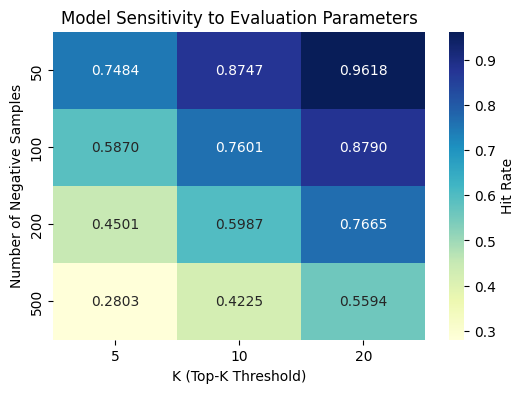

In [14]:

# Evaluate the model's performance with different number of negatives per positive and different 
# value thresholds
def evaluate_metric_sensitivity(model, test_df, full_df):
    k_values = [5, 10, 20]
 
    neg_values = [50, 100, 200, 500] 

    results = []
    print("Executing Evaluation Grid Search...")
    
    for neg in neg_values:
        for k in k_values:
            hit_rate = hit_at_k(model, test_df, full_df, K=k, num_neg=neg)
            results.append({'Num_Negatives': neg, 'K': k, 'Hit_Rate': hit_rate})
            print(f"Negatives={neg:3d} | K={k:2d} -> Hit@{k}: {hit_rate:.4f}")

    results_df = pd.DataFrame(results)
    pivot_df = results_df.pivot(index='Num_Negatives', columns='K', values='Hit_Rate')
    
    print("\n--- Hit Rate Matrix ---")
    print(pivot_df)
    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Hit Rate'})
    plt.title("Model Sensitivity to Evaluation Parameters")
    plt.ylabel("Number of Negative Samples")
    plt.xlabel("K (Top-K Threshold)")
    plt.show()


evaluate_metric_sensitivity(MF_model, test_df, df)

In [15]:

# 3. Evaluate it
hit_rate = hit_at_k(MF_model, test_df, df, K=10, num_neg=100)

print(f"Hit@10: {hit_rate:.4f}")

Hit@10: 0.7590


 I tried to visualise the embeddings using PCA analysis. Ended badly. 
 Turns out the first 2 axes only describe around 30% of the variance.
 t-SNE might be a good visualisation tool, It's implementation can be left for future work

User PCA Explained Variance: 0.3114
Item PCA Explained Variance: 0.2653


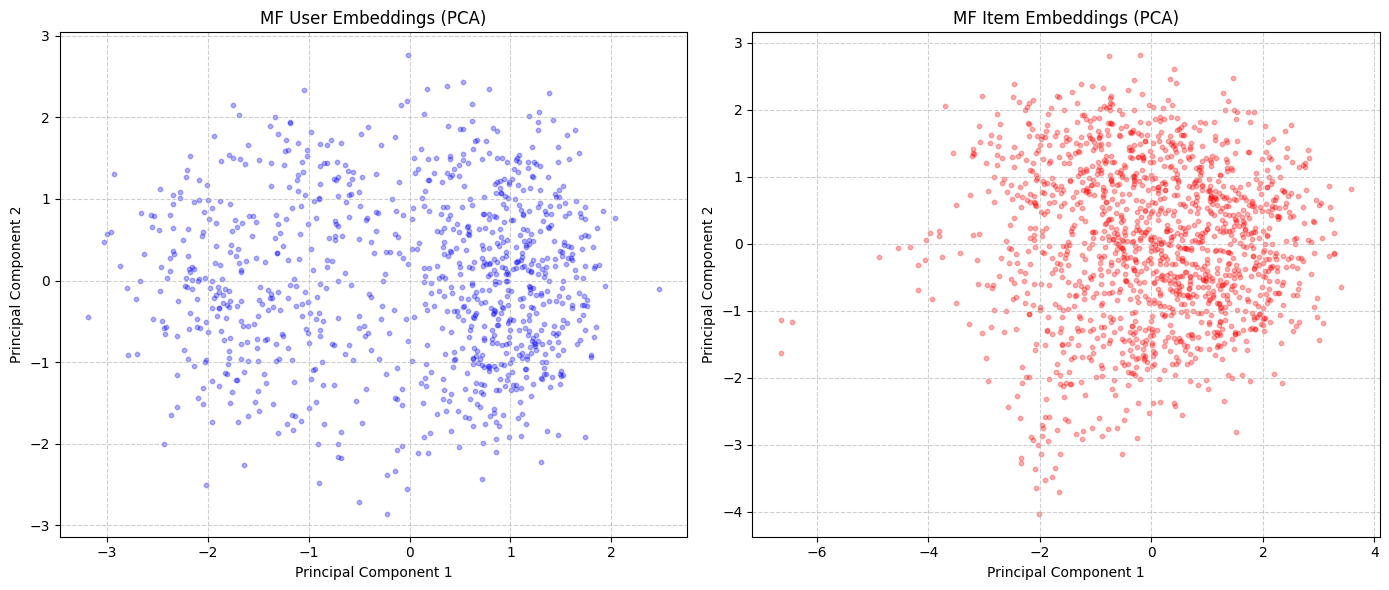

In [16]:

"""

"""
def visualize_mf_embeddings(model):
  
    mf_user_embs = model.user_emb.weight.detach().cpu().numpy()
    mf_item_embs = model.item_emb.weight.detach().cpu().numpy()

    # 2. Fit PCA to reduce the K-dimensional space to 2D
    pca_users = PCA(n_components=2)
    user_2d = pca_users.fit_transform(mf_user_embs)
    
    pca_items = PCA(n_components=2)
    item_2d = pca_items.fit_transform(mf_item_embs)

    # 3. Print variance ratios to see how much signal is preserved in 2D
    print(f"User PCA Explained Variance: {np.sum(pca_users.explained_variance_ratio_):.4f}")
    print(f"Item PCA Explained Variance: {np.sum(pca_items.explained_variance_ratio_):.4f}")

    # 4. Plot the geometries
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # User Plot
    axes[0].scatter(user_2d[:, 0], user_2d[:, 1], alpha=0.3, color='blue', s=10)
    axes[0].set_title("MF User Embeddings (PCA)")
    axes[0].set_xlabel("Principal Component 1")
    axes[0].set_ylabel("Principal Component 2")
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Item Plot
    axes[1].scatter(item_2d[:, 0], item_2d[:, 1], alpha=0.3, color='red', s=10)
    axes[1].set_title("MF Item Embeddings (PCA)")
    axes[1].set_xlabel("Principal Component 1")
    axes[1].set_ylabel("Principal Component 2")
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Execute the visualization
visualize_mf_embeddings(MF_model)

If your score is low, try playing with the hyperparameters before moving on! Try sampling more negatives, or playing with the embedding dimensions.

Conversely, if your score is high, play with the values of K or number of negatives in evaluation (dec K, inc negatives).

## Neural Model: MLP-Based Recommender

Instead of using a dot product, we can learn a more flexible interaction function using a neural network.

Approach:
- Learn user and item embeddings
- **Concatenate** them
- Pass through a **Multi-Layer Perceptron (MLP)**

This allows the model to capture more complex relationships than simple similarity.

---

### Your Task

Implement a model that:
1. Learns user and item embeddings
2. Concatenates them
3. Passes them through an MLP to produce a score

The choice of activation functions is upto you.

In [17]:
class MLP(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()

        # TODO:
        # - Define user embedding layer
        # - Define item embedding layer
        # - Define MLP layers


        """
        A simple funnel type architecture. 
        Additional complexity becomes meaningless for a dataset of this size
        """
        self.user_emb=nn.Embedding(num_users, emb_dim)
        self.item_emb=nn.Embedding(num_items, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(2 * emb_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, user, item):
        # TODO:
        # - Get embeddings
        # - Concatenate user and item embeddings
        # - Pass through MLP
        # - Return a single score
        user_emb = self.user_emb(user)
        item_emb = self.item_emb(item)
        concatenated = torch.cat([user_emb, item_emb], dim=1)
        return self.mlp(concatenated)[:,0]

## Train and Evaluate the MLP Model

Repeat the same steps as before:
- Train the model
- Evaluate on the test set

Compare its performance with the MF model.

In [18]:
# TODO:
# 1. Initialize MLP model
# 2. Train it
# 3. Evaluate it
MLP_model = MLP(num_users=df['user_id'].nunique(), num_items=df['item_id'].nunique(), emb_dim=32)
state_dict = torch.load('/kaggle/input/datasets/aneeshshastri/epoch-task-3/mlp_pretrained.pth', weights_only=True)
#MLP_model.load_state_dict(state_dict)


train(MLP_model, train_loader,valid_loader,valid_hit_loader,num_items=df['item_id'].nunique(), epochs=150)


Epoch 1: Train Loss: 0.2594 | Val Loss: 0.2310 | Val Hit@10: 0.5276
Epoch 2: Train Loss: 0.2255 | Val Loss: 0.2294 | Val Hit@10: 0.5382
Epoch 3: Train Loss: 0.2230 | Val Loss: 0.2289 | Val Hit@10: 0.5435
Epoch 4: Train Loss: 0.2205 | Val Loss: 0.2276 | Val Hit@10: 0.5414
Epoch 5: Train Loss: 0.2180 | Val Loss: 0.2251 | Val Hit@10: 0.5552
Epoch 6: Train Loss: 0.2132 | Val Loss: 0.2247 | Val Hit@10: 0.5870
Epoch 7: Train Loss: 0.2077 | Val Loss: 0.2188 | Val Hit@10: 0.6019
Epoch 8: Train Loss: 0.2009 | Val Loss: 0.2211 | Val Hit@10: 0.6019
Epoch 9: Train Loss: 0.1955 | Val Loss: 0.2227 | Val Hit@10: 0.6231
Epoch 10: Train Loss: 0.1904 | Val Loss: 0.2190 | Val Hit@10: 0.6210
Epoch 11: Train Loss: 0.1859 | Val Loss: 0.2175 | Val Hit@10: 0.6136
Epoch 12: Train Loss: 0.1819 | Val Loss: 0.2159 | Val Hit@10: 0.6263
Epoch 13: Train Loss: 0.1775 | Val Loss: 0.2182 | Val Hit@10: 0.6178
Epoch 14: Train Loss: 0.1751 | Val Loss: 0.2206 | Val Hit@10: 0.6380
Epoch 15: Train Loss: 0.1704 | Val Loss: 0.

[0.25935227224273544,
 0.2254700197434363,
 0.22295027441074144,
 0.22050121429823127,
 0.21799792981292954,
 0.21324970828237197,
 0.20766067067375904,
 0.2009242875627094,
 0.1955097165734885,
 0.19042440842174355,
 0.18592897237397216,
 0.18187869672362522,
 0.17753367190479766,
 0.1750709815659747,
 0.1704463683337738,
 0.16856390110445105,
 0.16487928197312843,
 0.16289335719045217,
 0.16021741320966068,
 0.15748879673844993,
 0.151882593112051,
 0.1498868930704078,
 0.14808183483918785,
 0.14740174138297096,
 0.14572345498801834,
 0.14456861063663,
 0.1416718914437263,
 0.1405246577956019,
 0.14024609772601093,
 0.13904789561367698,
 0.13866014330088444,
 0.1382853209797379,
 0.13619559717118715,
 0.1360698264382258,
 0.13554573082091653,
 0.13517921949441455,
 0.13473761902102027,
 0.13484358866611942,
 0.13389294813603825,
 0.13366398848544622,
 0.13345953922924553,
 0.13315637974232994,
 0.13340044731015793,
 0.13282407429223217,
 0.13270301670613835,
 0.13245343156693654,
 0.

Executing Evaluation Grid Search...
Negatives= 50 | K= 5 -> Hit@5: 0.6741
Negatives= 50 | K=10 -> Hit@10: 0.8397
Negatives= 50 | K=20 -> Hit@20: 0.9395
Negatives=100 | K= 5 -> Hit@5: 0.5372
Negatives=100 | K=10 -> Hit@10: 0.6996
Negatives=100 | K=20 -> Hit@20: 0.8397
Negatives=200 | K= 5 -> Hit@5: 0.3885
Negatives=200 | K=10 -> Hit@10: 0.5456
Negatives=200 | K=20 -> Hit@20: 0.7102
Negatives=500 | K= 5 -> Hit@5: 0.2304
Negatives=500 | K=10 -> Hit@10: 0.3641
Negatives=500 | K=20 -> Hit@20: 0.4968

--- Hit Rate Matrix ---
K                    5         10        20
Num_Negatives                              
50             0.674098  0.839703  0.939490
100            0.537155  0.699575  0.839703
200            0.388535  0.545648  0.710191
500            0.230361  0.364119  0.496815


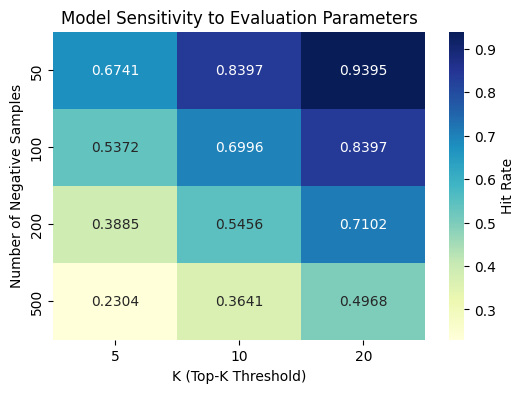

Hit@10: 0.7028


In [19]:
hit_rate = hit_at_k(MLP_model, test_df, df, K=10, num_neg=100)
evaluate_metric_sensitivity(MLP_model, test_df, df)
torch.save(MLP_model.state_dict(), 'mlp_pretrained.pth')
print(f"Hit@10: {hit_rate:.4f}")


## Comparison & Analysis

You have now implemented:
- Matrix Factorization (MF)
- MLP-based recommender

---

### Compare the Models

- What score did each model achieve? 
- Which model performed better?

---

### Think & Reflect

- Why might the MLP model outperform MF?
- In what cases might MF perform just as well or better?
- How does embedding size affect performance?
- Did you observe any signs of overfitting?
- (Yes)

---

### Some Experiments

If you want to explore further:
- Try different embedding dimensions
- Change number of MLP layers
- Try different activation functions

---

###### Bonus Task: Neural Collaborative Filtering (NCF)

In this task, you implemented:
- Matrix Factorization (MF)
- MLP-based recommender

The paper [Neural Collaborative Filtering](https://arxiv.org/pdf/1708.05031) proposes combining both ideas.

---

### Idea

- MF captures **linear interactions**
- MLP captures **nonlinear interactions**

NCF combines both by:
1. Computing MF output
2. Computing MLP output
3. Combining them into a final prediction

---

### Your Task

Design a model that:
- Uses both MF and MLP components
- Combines their outputs
- Trains end-to-end

---

### Hints

- You can:
  - Concatenate MF and MLP representations
  - Or combine their final scores
- Think about:
  - Should embeddings be shared or separate?
  - How to balance both components?

---

Does combining both approaches improve performance over MF and MLP individually?

(Tried to come up with my own design for combining MF and MLP approaches. The Model overfit wildly, however. Regardless it's worth looking at, and might perform well post fine tuning)

In [20]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, mf_dim=16, mlp_dim=16, layers=[64, 64, 16]):
        super(NCF, self).__init__()

        # Matrix Factorization (GMF) component
        self.mf_user_emb = nn.Embedding(num_users, mf_dim)
        self.mf_item_emb = nn.Embedding(num_items, mf_dim)

        self.mlp_user_emb = nn.Embedding(num_users, mlp_dim)
        self.mlp_item_emb = nn.Embedding(num_items, mlp_dim)
        mlp_modules = []
        input_size = mf_dim +2 * mlp_dim
        for output_size in layers:
            mlp_modules.append(nn.Linear(input_size, output_size))
            mlp_modules.append(nn.ReLU())
            input_size = output_size
            
        self.mlp_network = nn.Sequential(*mlp_modules)
        self.prediction_layer = nn.Linear(layers[-1], 1)

    def forward(self, user, item):
        # GMF Branch
        mf_user = self.mf_user_emb(user)
        mf_item = self.mf_item_emb(item)
        mf_output = mf_user * mf_item # element-wise product

        # MLP Branch
        mlp_user = self.mlp_user_emb(user)
        mlp_item = self.mlp_item_emb(item)
        mlp_input = torch.cat([mf_output,mlp_user, mlp_item], dim=1)
        mlp_output = self.mlp_network(mlp_input)

        return self.prediction_layer(mlp_output).squeeze()

The standard method that was demonstrated in the research paper where NeuMCF was proposed

In [21]:
class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, mf_dim=16, mlp_dim=32, layers=[128, 64, 16]):
        super(NeuMF, self).__init__()

        # Matrix Factorization (GMF) component
        self.mf_user_emb = nn.Embedding(num_users, mf_dim)
        self.mf_item_emb = nn.Embedding(num_items, mf_dim)

        # MLP component
        self.mlp_user_emb = nn.Embedding(num_users, mlp_dim)
        self.mlp_item_emb = nn.Embedding(num_items, mlp_dim)

        mlp_modules = []
        input_size = 2 * mlp_dim
        for output_size in layers:
            mlp_modules.append(nn.Linear(input_size, output_size))
            mlp_modules.append(nn.ReLU())
            input_size = output_size
        self.mlp_network = nn.Sequential(*mlp_modules)

        # Final Prediction Layer (Combines both outputs)
        self.prediction_layer = nn.Linear(mf_dim + layers[-1], 1)

    def forward(self, user, item):
        # GMF Branch
        mf_user = self.mf_user_emb(user)
        mf_item = self.mf_item_emb(item)
        mf_output = mf_user * mf_item # element-wise product

        # MLP Branch
        mlp_user = self.mlp_user_emb(user)
        mlp_item = self.mlp_item_emb(item)
        mlp_input = torch.cat([mlp_user, mlp_item], dim=1)
        mlp_output = self.mlp_network(mlp_input)

        # Concatenate GMF and MLP outputs
        combined = torch.cat([mf_output, mlp_output], dim=1)

        # Output layer
        return self.prediction_layer(combined).squeeze()

In [22]:
# 1. Initialize NCF model
NCF_model = NeuMF(num_users=df['user_id'].nunique(), num_items=df['item_id'].nunique(), mf_dim=16, mlp_dim=32)

# --- 2. Load the state dictionaries ---
gmf_state = torch.load('gmf_pretrained.pth')
mlp_state = torch.load('mlp_pretrained.pth')

# --- 3. Initialize the NCF Model ---
with torch.no_grad():
    # Inject GMF embeddings
    NCF_model.mf_user_emb.weight.copy_(gmf_state['user_emb.weight'])
    NCF_model.mf_item_emb.weight.copy_(gmf_state['item_emb.weight'])
    
    # Inject MLP embeddings
    NCF_model.mlp_user_emb.weight.copy_(mlp_state['user_emb.weight'])
    NCF_model.mlp_item_emb.weight.copy_(mlp_state['item_emb.weight'])
            
    # Note: If following the exact paper, the final prediction layer 'h' 
    # is initialized as the concatenation of the GMF and MLP final layers multiplied by an alpha weight.
    # However I decided only to initialise the embeddings and keep the model weights as random.
print("Starting NCF training...")
train(NCF_model, train_loader, valid_loader,valid_hit_loader,num_items=df['item_id'].nunique(), epochs=50,lr=1e-4)


Starting NCF training...
Epoch 1: Train Loss: 0.2338 | Val Loss: 0.2130 | Val Hit@10: 0.6306
Epoch 2: Train Loss: 0.1760 | Val Loss: 0.1972 | Val Hit@10: 0.6837
Epoch 3: Train Loss: 0.1548 | Val Loss: 0.1951 | Val Hit@10: 0.7017
Epoch 4: Train Loss: 0.1434 | Val Loss: 0.1942 | Val Hit@10: 0.7134
Epoch 5: Train Loss: 0.1358 | Val Loss: 0.1961 | Val Hit@10: 0.6890
Epoch 6: Train Loss: 0.1307 | Val Loss: 0.2018 | Val Hit@10: 0.6921
Epoch 7: Train Loss: 0.1273 | Val Loss: 0.2014 | Val Hit@10: 0.6985
Epoch 8: Train Loss: 0.1246 | Val Loss: 0.2121 | Val Hit@10: 0.6985
Epoch 9: Train Loss: 0.1231 | Val Loss: 0.2166 | Val Hit@10: 0.6868
Epoch 10: Train Loss: 0.1212 | Val Loss: 0.2108 | Val Hit@10: 0.6964
Epoch 11: Train Loss: 0.1199 | Val Loss: 0.2203 | Val Hit@10: 0.6996
Epoch 12: Train Loss: 0.1199 | Val Loss: 0.2194 | Val Hit@10: 0.6900
Epoch 13: Train Loss: 0.1189 | Val Loss: 0.2229 | Val Hit@10: 0.6815
Epoch 14: Train Loss: 0.1190 | Val Loss: 0.2223 | Val Hit@10: 0.6762
Epoch 15: Train Lo

[0.23378094811382993,
 0.17601800903438122,
 0.1547831778956165,
 0.14336772179761728,
 0.1357543020630308,
 0.13068916448669468,
 0.12725545635925734,
 0.12462119323214846,
 0.12306741223536455,
 0.12119021742447089,
 0.11988850836911477,
 0.1199189882065976,
 0.11892880332786242,
 0.11901497894030334,
 0.11827452798228566,
 0.11702155687883918,
 0.11772060982976959,
 0.11725125438807166,
 0.11704269091575599,
 0.11688960334201023,
 0.11644578601463353,
 0.11626190589453252,
 0.11659793935395314,
 0.11546700309578001,
 0.11600966345180165,
 0.11576191883772391,
 0.11607659504906465,
 0.11538853088297393,
 0.11520634982094863,
 0.11566508271159842,
 0.115225064754162,
 0.11535335590932462,
 0.11562680010693963,
 0.11497777139281075,
 0.11479672296325141,
 0.1151747941474984,
 0.11548959842197218,
 0.11510800703932224,
 0.11517905991114498,
 0.11452536833913703,
 0.11479566513798506,
 0.11505893844885896,
 0.11548221846309212,
 0.11525753081305072,
 0.1150076190717016,
 0.11529527597450

In [23]:

# 3. Evaluate it

ncf_hit_rate = hit_at_k(NCF_model, test_df, df, K=10, num_neg=100)
print(f"NCF Hit@10: {ncf_hit_rate:.4f}")

NCF Hit@10: 0.7463


Executing Evaluation Grid Search...
Negatives= 50 | K= 5 -> Hit@5: 0.7452
Negatives= 50 | K=10 -> Hit@10: 0.8694
Negatives= 50 | K=20 -> Hit@20: 0.9692
Negatives=100 | K= 5 -> Hit@5: 0.6051
Negatives=100 | K=10 -> Hit@10: 0.7558
Negatives=100 | K=20 -> Hit@20: 0.8885
Negatives=200 | K= 5 -> Hit@5: 0.4650
Negatives=200 | K=10 -> Hit@10: 0.6242
Negatives=200 | K=20 -> Hit@20: 0.7739
Negatives=500 | K= 5 -> Hit@5: 0.3047
Negatives=500 | K=10 -> Hit@10: 0.4374
Negatives=500 | K=20 -> Hit@20: 0.5722

--- Hit Rate Matrix ---
K                    5         10        20
Num_Negatives                              
50             0.745223  0.869427  0.969214
100            0.605096  0.755839  0.888535
200            0.464968  0.624204  0.773885
500            0.304671  0.437367  0.572187


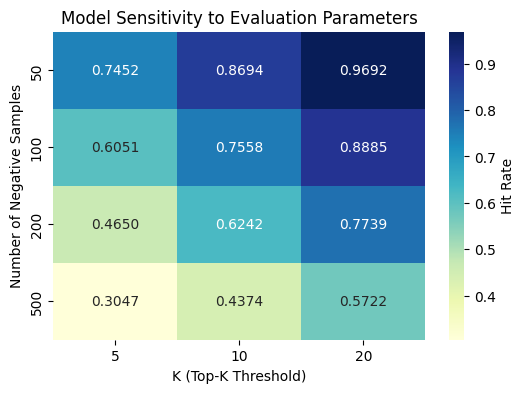

In [24]:
evaluate_metric_sensitivity(NCF_model, test_df, df)